<a href="https://colab.research.google.com/github/elifnurerdemir/DI725_Term_Project/blob/main/DI725_TermProject_Phase2_ElifnurErdemir.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DI 725 – Transformers and Attention-Based Deep Networks
## Term Project – Phase 2: Results & Benchmarking

Environment Setup

In [ ]:
# Install required packages
!pip install torch torchvision transformers pandas Pillow scikit-learn wandb --quiet

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from transformers import AutoTokenizer, AutoModel, ViTModel, ViTConfig
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, hamming_loss, classification_report
import matplotlib.pyplot as plt
import wandb

SEED = 42

def set_seed(seed: int) -> None:
    """Seed everything for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
print(f"Seed set to {SEED}")

Seed set to 42


In [ ]:
from IPython.display import clear_output

class EpochVisualizer:
    """
    Live-updating training dashboard .

    Call `visualizer.update(epoch, train_metrics, val_metrics)` at the end of
    every epoch. The figure is redrawn in-place using clear_output so only
    the latest state is visible.

    Tracked metrics per epoch:
      train: cls_loss, grnd_loss
      val:   micro_f1, macro_f1, hamming, alpha_mean, alpha_std, f1_<class>
    """

    def __init__(self, classes: list, experiment_name: str):
        self.classes         = classes
        self.experiment_name = experiment_name

        # History buffers
        self.epochs      = []
        self.train_cls   = []
        self.train_grnd  = []
        self.val_micro   = []
        self.val_macro   = []
        self.val_hamming = []
        self.alpha_mean  = []
        self.alpha_std   = []
        self.per_class   = {cls: [] for cls in classes}  # val F1 per class

    def update(
        self,
        epoch: int,
        train_m: dict,
        val_m: dict,
    ) -> None:
        self.epochs.append(epoch)
        self.train_cls.append(train_m['cls_loss'])
        self.train_grnd.append(train_m['grnd_loss'])
        self.val_micro.append(val_m['micro_f1'])
        self.val_macro.append(val_m['macro_f1'])
        self.val_hamming.append(val_m['hamming'])
        self.alpha_mean.append(val_m['alpha_mean'])
        self.alpha_std.append(val_m['alpha_std'])
        for cls in self.classes:
            self.per_class[cls].append(val_m[f'f1_{cls}'])

        self._draw()

    def _draw(self) -> None:
        clear_output(wait=True)

        fig, axes = plt.subplots(2, 3, figsize=(15, 8))
        fig.suptitle(
            f'{self.experiment_name} – Training Dashboard  '
            f'(Epoch {self.epochs[-1]})',
            fontsize=13, fontweight='bold',
        )

        ep = self.epochs

        ax = axes[0, 0]
        ax.plot(ep, self.train_cls,  marker='o', linestyle='-',  label='Classification Loss')
        ax.plot(ep, self.train_grnd, marker='s', linestyle='--', label='Grounding Loss')
        ax.set_title('Training Loss')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.legend(fontsize=8)
        ax.grid(True, linestyle=':')

        ax = axes[0, 1]
        ax.plot(ep, self.val_micro, marker='^', linestyle='-', color='tab:green')
        ax.set_title('Validation Micro-F1')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Micro-F1')
        ax.set_ylim(0, 1)
        ax.annotate(
            f'{self.val_micro[-1]:.4f}',
            xy=(ep[-1], self.val_micro[-1]),
            xytext=(5, -12), textcoords='offset points', fontsize=9,
        )
        ax.grid(True, linestyle=':')

        # Validation Macro-F1 Table
        ax = axes[0, 2]
        ax.plot(ep, self.val_macro, marker='D', linestyle='-', color='tab:orange')
        ax.set_title('Validation Macro-F1')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Macro-F1')
        ax.set_ylim(0, 1)
        ax.annotate(
            f'{self.val_macro[-1]:.4f}',
            xy=(ep[-1], self.val_macro[-1]),
            xytext=(5, -12), textcoords='offset points', fontsize=9,
        )
        ax.grid(True, linestyle=':')

        # Hamming Loss Table
        ax = axes[1, 0]
        ax.plot(ep, self.val_hamming, marker='x', linestyle='-', color='tab:red')
        ax.set_title('Validation Hamming Loss')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Hamming Loss')
        ax.set_ylim(0, max(self.val_hamming) * 1.2 + 1e-6)
        ax.annotate(
            f'{self.val_hamming[-1]:.4f}',
            xy=(ep[-1], self.val_hamming[-1]),
            xytext=(5, 5), textcoords='offset points', fontsize=9,
        )
        ax.grid(True, linestyle=':')

        # Dynamic Reliability Coefficient α
        ax = axes[1, 1]
        means = np.array(self.alpha_mean)
        stds  = np.array(self.alpha_std)
        ax.plot(ep, means, marker='o', linestyle='-', color='tab:purple', label='Mean α')
        ax.fill_between(ep, means - stds, means + stds, alpha=0.25, color='tab:purple', label='±1 std')
        ax.axhline(0.5, color='grey', linestyle=':', linewidth=1, label='α=0.5 (balanced)')
        ax.set_title('Dynamic Reliability Coefficient α')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('α')
        ax.set_ylim(0, 1)
        ax.legend(fontsize=8)
        ax.grid(True, linestyle=':')

        # Per-class F1 (latest epoch)
        ax = axes[1, 2]
        latest_f1 = [self.per_class[cls][-1] for cls in self.classes]
        bars = ax.bar(
            self.classes, latest_f1,
            edgecolor='black',
            color=[
                'tab:green', 'tab:pink', 'tab:olive',
                'tab:orange', 'tab:brown', 'tab:gray', 'tab:blue'
            ],
        )
        ax.set_title(f'Per-Class F1 (Epoch {ep[-1]})')
        ax.set_ylabel('F1 Score')
        ax.set_ylim(0, 1)
        ax.tick_params(axis='x', rotation=20)
        for bar, val in zip(bars, latest_f1):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.02,
                f'{val:.2f}', ha='center', va='bottom', fontsize=7,
            )
        ax.grid(axis='y', linestyle=':')

        plt.tight_layout()
        plt.show()

1. Configuration


In [ ]:
#  Paths
BASE_PATH      = r'/content/drive/MyDrive/DI725_project_dataset'
IMG_DIR        = os.path.join(BASE_PATH, 'images')
MASK_DIR       = os.path.join(BASE_PATH, 'masks')
LABELS_CSV     = os.path.join(BASE_PATH, 'binary_labels.csv')
CAPTIONS_CSV   = os.path.join(BASE_PATH, 'vision_captions_only.csv')

# ── Model & Training
DEVICE         = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CLASSES        = ['Tree', 'Shrub', 'Grass', 'Crop', 'Built-up', 'Barren', 'Water']
NUM_CLASSES    = len(CLASSES)
IMG_SIZE       = 224            # ViT-B/16 expects 224×224
PATCH_SIZE     = 16             # ViT-B/16 patch size
ATTN_GRID      = IMG_SIZE // PATCH_SIZE   # 14 – attention map spatial resolution
MAX_TEXT_LEN   = 128
BATCH_SIZE     = 32
NUM_EPOCHS     = 10
LEARNING_RATE  = 3e-5
VAL_SPLIT      = 0.15
TEST_SPLIT     = 0.10
ATTN_LOSS_W    = 0.1            # weight for the attention grounding loss term
VIT_EMBED_DIM  = 768
TEXT_EMBED_DIM = 768
CAPTION_COL    = 'vision_qwen3-vl-8b'
TEXT_MODEL_ID  = 'distilbert-base-uncased'

# Class colours
CLASS_RGB = {
    'Tree':     (0,   100,   0),
    'Shrub':    (255, 182, 193),
    'Grass':    (154, 205,  50),
    'Crop':     (255, 215,   0),
    'Built-up': (139,  69,  19),
    'Barren':   (211, 211, 211),
    'Water':    (0,     0, 255),
}

print(f"Device: {DEVICE}")
print(f"Attention grid: {ATTN_GRID}×{ATTN_GRID}")

Device: cuda
Attention grid: 14×14


## 2. Dataset

### 2.1 Mask Decoding

The RGB segmentation masks are decoded per-class into binary spatial maps.  
Each map is then resized to `ATTN_GRID × ATTN_GRID` to match the ViT attention resolution.

This produces a **per-class presence mask** that is later used as the supervision signal for Attention Grounding.

In [ ]:
def decode_mask(mask_path: str, class_rgb: dict, classes: list, grid: int) -> torch.Tensor:
    """
    Decode an RGB segmentation mask into a float tensor of shape (num_classes, grid, grid).
    Each channel contains a binary map indicating where that class is present,
    then bicubic-downsampled to the ViT attention resolution.

    Args:
        mask_path: Path to the RGB mask image.
        class_rgb: Mapping of class name to (R, G, B) tuple.
        classes:   Ordered list of class names.
        grid:      Spatial resolution for the output (ATTN_GRID).

    Returns:
        Tensor of shape (num_classes, grid, grid), values in [0, 1].
    """
    mask_img = np.array(Image.open(mask_path).convert('RGB'))  # (H, W, 3)
    H, W = mask_img.shape[:2]
    maps = []
    for cls in classes:
        r, g, b = class_rgb[cls]
        # Exact pixel match for each class colour
        binary = (
            (mask_img[:, :, 0] == r) &
            (mask_img[:, :, 1] == g) &
            (mask_img[:, :, 2] == b)
        ).astype(np.float32)  # (H, W)
        maps.append(binary)
    stacked = np.stack(maps, axis=0)  # (C, H, W)
    tensor  = torch.from_numpy(stacked).unsqueeze(0)  # (1, C, H, W)
    resized = F.interpolate(tensor, size=(grid, grid), mode='nearest')
    return resized.squeeze(0)  # (C, grid, grid)

### 2.2 Dataset Class

In [ ]:
class RemoteSensingDataset(Dataset):
    """
    Multi-modal remote sensing dataset.

    Returns a dict with:
      - image      : (3, 224, 224) normalised image tensor
      - input_ids  : (max_text_len,) token IDs from DistilBERT tokeniser
      - attn_mask  : (max_text_len,) attention mask for text
      - labels     : (num_classes,) binary multi-label targets
      - gt_attn    : (num_classes, ATTN_GRID, ATTN_GRID) per-class spatial mask
      - filename   : original filename string (for debugging)
    """

    def __init__(
        self,
        labels_df: pd.DataFrame,
        captions_df: pd.DataFrame,
        img_dir: str,
        mask_dir: str,
        class_rgb: dict,
        classes: list,
        attn_grid: int,
        transform=None,
        tokenizer=None,
        max_text_len: int = 128,
        caption_col: str = 'vision_qwen3-vl-8b',
    ):
        self.labels_df   = labels_df.reset_index(drop=True)
        self.captions    = captions_df.set_index('filename')[caption_col].to_dict()
        self.img_dir     = img_dir
        self.mask_dir    = mask_dir
        self.class_rgb   = class_rgb
        self.classes     = classes
        self.attn_grid   = attn_grid
        self.transform   = transform
        self.tokenizer   = tokenizer
        self.max_text_len = max_text_len

    def __len__(self) -> int:
        return len(self.labels_df)

    def __getitem__(self, idx: int) -> dict:
        row      = self.labels_df.iloc[idx]
        fname    = row['filename']

        # Image
        image = Image.open(os.path.join(self.img_dir, fname)).convert('RGB')
        if self.transform:
            image = self.transform(image)

        # Segmentation mask (decoded to per-class attention targets)
        gt_attn = decode_mask(
            os.path.join(self.mask_dir, fname),
            self.class_rgb, self.classes, self.attn_grid
        )  # (num_classes, grid, grid)

        # Caption
        caption  = str(self.captions.get(fname, ''))
        encoding = self.tokenizer(
            caption,
            padding='max_length',
            truncation=True,
            max_length=self.max_text_len,
            return_tensors='pt',
        )

        # Labels
        labels = torch.tensor(row[self.classes].values.astype(float), dtype=torch.float32)

        return {
            'image':     image,
            'input_ids': encoding['input_ids'].squeeze(0),
            'attn_mask': encoding['attention_mask'].squeeze(0),
            'labels':    labels,
            'gt_attn':   gt_attn,
            'filename':  fname,
        }

### 2.3 Data Loading

In [ ]:
def build_dataloaders(
    labels_csv: str,
    captions_csv: str,
    img_dir: str,
    mask_dir: str,
    class_rgb: dict,
    classes: list,
    attn_grid: int,
    text_model_id: str,
    batch_size: int,
    val_split: float,
    test_split: float,
    max_text_len: int,
    caption_col: str,
    seed: int,
):
    """Load CSVs, split, and return (train_loader, val_loader, test_loader)."""
    labels_df   = pd.read_csv(labels_csv)
    captions_df = pd.read_csv(captions_csv)

    tokenizer = AutoTokenizer.from_pretrained(text_model_id)

    img_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])

    # Tandom splitting
    train_val_df, test_df = train_test_split(labels_df, test_size=test_split,  random_state=seed)
    train_df,    val_df  = train_test_split(train_val_df, test_size=val_split / (1 - test_split), random_state=seed)

    dataset_kwargs = dict(
        captions_df=captions_df,
        img_dir=img_dir, mask_dir=mask_dir,
        class_rgb=class_rgb, classes=classes,
        attn_grid=attn_grid,
        transform=img_transform,
        tokenizer=tokenizer,
        max_text_len=max_text_len,
        caption_col=caption_col,
    )

    train_loader = DataLoader(
        RemoteSensingDataset(labels_df=train_df, **dataset_kwargs),
        batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True,
    )
    val_loader = DataLoader(
        RemoteSensingDataset(labels_df=val_df, **dataset_kwargs),
        batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True,
    )
    test_loader = DataLoader(
        RemoteSensingDataset(labels_df=test_df, **dataset_kwargs),
        batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True,
    )

    print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
    return train_loader, val_loader, test_loader


train_loader, val_loader, test_loader = build_dataloaders(
    labels_csv=LABELS_CSV, captions_csv=CAPTIONS_CSV,
    img_dir=IMG_DIR, mask_dir=MASK_DIR,
    class_rgb=CLASS_RGB, classes=CLASSES,
    attn_grid=ATTN_GRID, text_model_id=TEXT_MODEL_ID,
    batch_size=BATCH_SIZE, val_split=VAL_SPLIT, test_split=TEST_SPLIT,
    max_text_len=MAX_TEXT_LEN, caption_col=CAPTION_COL,
    seed=SEED,
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train: 7500 | Val: 1500 | Test: 1000


## 3. Model Architecture

 3.2 ViT Attention Extraction

In [ ]:
class ViTWithAttention(nn.Module):
    """
    Wraps HuggingFace ViTModel and exposes per-class attention maps
    from the last encoder layer.

    Instead of a single averaged attention map, we assign each attention
    head to a class in round-robin fashion and average within each group.
    This gives the grounding loss a class-specific supervision signal.

    Returns:
        cls_feat    : (batch, 768)                          – CLS token embedding
        attn_map    : (batch, num_classes, ATTN_GRID, ATTN_GRID) – per-class attention
    """

    def __init__(
        self,
        model_id: str   = 'google/vit-base-patch16-224',
        attn_grid: int  = 14,
        num_classes: int = 7,
    ):
        super().__init__()
        self.vit        = ViTModel.from_pretrained(model_id, output_attentions=True)
        self.attn_grid  = attn_grid
        self.num_classes = num_classes
        self.num_heads   = 12   # ViT-B/16 has 12 attention heads

        # Pre-compute head → class assignment (round-robin)
        # e.g. heads [0,7] → class 0, heads [1,8] → class 1, …
        self.head_to_class = [h % num_classes for h in range(self.num_heads)]

    def forward(self, pixel_values: torch.Tensor):
        outputs  = self.vit(pixel_values=pixel_values)
        cls_feat = outputs.last_hidden_state[:, 0]           # (B, 768)

        # outputs.attentions: tuple of (B, heads, tokens, tokens) per layer
        last_attn = outputs.attentions[-1]                   # (B, 12, 197, 197)
        # CLS token row, patch columns only
        cls_attn  = last_attn[:, :, 0, 1:]                  # (B, 12, 196)

        B = cls_attn.shape[0]

        # Build per-class attention by averaging assigned heads
        per_class_maps = []
        for c in range(self.num_classes):
            head_indices = [h for h, cls in enumerate(self.head_to_class) if cls == c]
            c_attn = cls_attn[:, head_indices, :].mean(dim=1)   # (B, 196)

            # Normalise to [0, 1] per sample for stable supervision
            c_min  = c_attn.min(dim=1, keepdim=True).values
            c_max  = c_attn.max(dim=1, keepdim=True).values
            c_norm = (c_attn - c_min) / (c_max - c_min + 1e-8)

            per_class_maps.append(
                c_norm.reshape(B, self.attn_grid, self.attn_grid)  # (B, 14, 14)
            )

        # Stack to (B, num_classes, 14, 14)
        attn_map = torch.stack(per_class_maps, dim=1)

        return cls_feat, attn_map


### 3.3 Full Gated Multi-Modal Model

In [ ]:
class GatedMultiModalModel(nn.Module):
    """
    Multi-modal land cover classifier with:
      - ViT-B/16 image encoder with per-class attention extraction
      - DistilBERT text encoder
      - Dynamic Reliability Gate (produces α per sample)
      - Per-class Attention Grounding (each class supervised by its own mask)

    Forward returns:
      logits   : (B, num_classes)                          – raw classification scores
      alpha    : (B, 1)                                    – reliability coefficient
      attn_map : (B, num_classes, ATTN_GRID, ATTN_GRID)   – per-class attention
    """

    def __init__(
        self,
        num_classes: int,
        vit_embed_dim: int   = 768,
        text_embed_dim: int  = 768,
        gate_hidden_dim: int = 256,
        attn_grid: int       = 14,
        text_model_id: str   = 'distilbert-base-uncased',
    ):
        super().__init__()

        # Vision encoder (now per-class attention)
        self.vision_encoder = ViTWithAttention(
            attn_grid=attn_grid, num_classes=num_classes
        )

        # Text encoder
        self.text_encoder = AutoModel.from_pretrained(text_model_id)

        # Dynamic Reliability Gate
        self.gate = nn.Sequential(
            nn.Linear(vit_embed_dim + text_embed_dim, gate_hidden_dim),
            nn.ReLU(),
            nn.Linear(gate_hidden_dim, 1),
            nn.Sigmoid(),
        )

        # Classification head
        self.classifier = nn.Linear(vit_embed_dim, num_classes)

    def forward(
        self,
        pixel_values: torch.Tensor,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor,
    ):
        # Visual features & per-class attention maps
        v_feat, attn_map = self.vision_encoder(pixel_values)
        # v_feat   : (B, 768)
        # attn_map : (B, num_classes, 14, 14)

        # Text features (CLS token)
        t_out  = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
        t_feat = t_out.last_hidden_state[:, 0]                # (B, 768)

        # Dynamic Reliability Coefficient α
        alpha  = self.gate(torch.cat([v_feat, t_feat], dim=1))  # (B, 1)

        # Weighted fusion
        fused  = alpha * v_feat + (1.0 - alpha) * t_feat         # (B, 768)

        # Classification
        logits = self.classifier(fused)                           # (B, num_classes)

        return logits, alpha, attn_map


## 4. Benchmarking Baseline

### Baseline Design

To evaluate the contribution of the proposed method, we compare it against a **Vision-Only Baseline**:
- Uses ViT-B/16 image features only (no text, no gate, no attention grounding)


In [ ]:
class VisionOnlyBaseline(nn.Module):
    """
    Baseline: ViT-B/16 image features → linear classifier.
    No text modality, no reliability gate, no attention grounding.
    Uses per-class attention maps for interface consistency with the full model.
    """

    def __init__(self, num_classes: int, attn_grid: int = 14):
        super().__init__()
        self.vision_encoder = ViTWithAttention(
            attn_grid=attn_grid, num_classes=num_classes
        )
        self.classifier = nn.Linear(768, num_classes)

    def forward(
        self,
        pixel_values: torch.Tensor,
        input_ids: torch.Tensor = None,
        attention_mask: torch.Tensor = None,
    ):
        v_feat, attn_map = self.vision_encoder(pixel_values)
        logits           = self.classifier(v_feat)
        alpha            = torch.ones(v_feat.shape[0], 1, device=v_feat.device)
        return logits, alpha, attn_map


## 5. Training Infrastructure

In [ ]:
def compute_pos_weights(labels_df: pd.DataFrame, classes: list, device) -> torch.Tensor:
    """
    Compute per-class positive weights for BCEWithLogitsLoss to handle
    class imbalance in multi-label classification.

    pos_weight[c] = (N - n_pos[c]) / n_pos[c]
    where N is total samples and n_pos[c] is the count of positive examples
    for class c. Rare classes (few positives) get higher weights.

    Args:
        labels_df : DataFrame with binary class columns
        classes   : ordered list of class names
        device    : torch device

    Returns:
        Tensor of shape (num_classes,) on the given device
    """
    counts  = labels_df[classes].sum(axis=0).values.astype(float)
    N       = float(len(labels_df))
    weights = (N - counts) / (counts + 1e-6)
    weights = np.clip(weights, 0.5, 10.0)
    print("Class positive weights:")
    for cls, w in zip(classes, weights):
        print(f"  {cls:10s}: {w:.3f}  (pos_count={int(counts[list(classes).index(cls)])})")
    return torch.tensor(weights, dtype=torch.float32, device=device)


def compute_metrics(preds: np.ndarray, targets: np.ndarray, classes: list) -> dict:
    """
    Compute multi-label classification metrics.

    Args:
        preds:   (N, C) binary predictions
        targets: (N, C) binary ground-truth
        classes: list of class names

    Returns:
        dict with micro_f1, macro_f1, hamming_loss, and per-class F1 scores
    """
    metrics = {
        'micro_f1':    f1_score(targets, preds, average='micro',  zero_division=0),
        'macro_f1':    f1_score(targets, preds, average='macro',  zero_division=0),
        'hamming':     hamming_loss(targets, preds),
    }
    per_class_f1 = f1_score(targets, preds, average=None, zero_division=0)
    for cls, score in zip(classes, per_class_f1):
        metrics[f'f1_{cls}'] = score
    return metrics


def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer,
    device: torch.device,
    attn_loss_w: float,
    classes: list,
    is_train: bool = True,
    use_attn_grounding: bool = True,
    pos_weight: torch.Tensor = None,
    gate_entropy_w: float = 0.01,
) -> dict:
    """
    Run one epoch (training or evaluation).

    Fixes applied in this version:
      1. pos_weight in BCEWithLogitsLoss for class-imbalance correction.
      2. Per-class attention grounding supervised against per-class masks.
      3. Gate entropy regularisation to prevent α collapsing to 1.
         L_entropy = -(α·log α + (1-α)·log(1-α))  [maximised → α stays near 0.5]
         Only applied during training; coefficient controlled by gate_entropy_w.

    Returns a dict with loss components and classification metrics.
    """
    model.train(is_train)
    total_cls_loss    = 0.0
    total_grnd_loss   = 0.0
    total_entropy_loss = 0.0
    all_preds, all_targets = [], []
    alpha_list = []

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for batch in loader:
            imgs     = batch['image'].to(device, non_blocking=True)
            ids      = batch['input_ids'].to(device, non_blocking=True)
            attn_msk = batch['attn_mask'].to(device, non_blocking=True)
            labels   = batch['labels'].to(device, non_blocking=True)
            gt_attn  = batch['gt_attn'].to(device, non_blocking=True)  # (B, C, grid, grid)

            if is_train:
                optimizer.zero_grad()

            logits, alpha, attn_map = model(imgs, ids, attn_msk)
            # attn_map : (B, num_classes, 14, 14)  — per-class

            # Classification loss with pos_weight
            cls_loss = F.binary_cross_entropy_with_logits(
                logits, labels, pos_weight=pos_weight
            )

            # Per-class attention grounding
            grnd_loss = torch.tensor(0.0, device=device)
            if use_attn_grounding:
                num_classes = labels.shape[1]
                per_class_losses = []
                for c in range(num_classes):
                    present = labels[:, c].bool()
                    if present.sum() == 0:
                        continue
                    pred_c = attn_map[present, c, :, :]
                    gt_c   = gt_attn[present, c, :, :]
                    per_class_losses.append(F.mse_loss(pred_c, gt_c))
                if per_class_losses:
                    grnd_loss = torch.stack(per_class_losses).mean()

            # Fix 3: Gate entropy regularisation
            # Maximise binary entropy of α to prevent gate collapse to 0 or 1.
            # entropy(α) = -(α·logα + (1-α)·log(1-α)), maximised at α=0.5
            # We subtract it from the loss (maximising entropy = minimising -entropy).
            # Applied only during training and skipped for VisionOnly (α is constant 1).
            entropy_loss = torch.tensor(0.0, device=device)
            if is_train and gate_entropy_w > 0:
                eps = 1e-8
                entropy = -(alpha * torch.log(alpha + eps) +
                            (1 - alpha) * torch.log(1 - alpha + eps))
                entropy_loss = entropy.mean()

            loss = cls_loss + attn_loss_w * grnd_loss - gate_entropy_w * entropy_loss

            if is_train:
                loss.backward()
                optimizer.step()

            total_cls_loss     += cls_loss.item()
            total_grnd_loss    += grnd_loss.item()
            total_entropy_loss += entropy_loss.item()

            preds = (torch.sigmoid(logits) > 0.5).int().cpu().numpy()
            all_preds.append(preds)
            all_targets.append(labels.cpu().numpy())
            alpha_list.append(alpha.detach().cpu())

    all_preds   = np.vstack(all_preds)
    all_targets = np.vstack(all_targets)
    alpha_all   = torch.cat(alpha_list).squeeze(1).numpy()

    metrics = compute_metrics(all_preds, all_targets, classes)
    n = len(loader)
    metrics['cls_loss']     = total_cls_loss     / n
    metrics['grnd_loss']    = total_grnd_loss     / n
    metrics['entropy_loss'] = total_entropy_loss  / n
    metrics['alpha_mean']   = float(alpha_all.mean())
    metrics['alpha_std']    = float(alpha_all.std())

    return metrics


In [ ]:
def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    num_epochs: int,
    lr: float,
    attn_loss_w: float,
    device: torch.device,
    classes: list,
    use_attn_grounding: bool,
    experiment_name: str,
    pos_weight: torch.Tensor = None,
    gate_entropy_w: float = 0.01,
    wandb_project: str = 'DI725_Phase2',
) -> list:
    """
    Train and validate a model, logging to WandB.

    Fix applied: separate learning rates per parameter group so the gate
    can learn independently of the frozen pretrained encoders.
      - Pretrained encoders (ViT, DistilBERT): lr / 30  (fine-tune slowly)
      - Gate network:                           lr * 10  (explore quickly)
      - Classifier head:                        lr       (default)

    This prevents the gate from immediately collapsing to α=1 because
    the ViT features dominate early in training.
    """
    model.to(device)

    # ── Fix: per-group learning rates ────────────────────────────────────────
    # Identify gate parameters by name so we don't accidentally include
    # encoder params even if the model is extended later.
    gate_params       = list(model.gate.parameters())       if hasattr(model, 'gate')       else []
    classifier_params = list(model.classifier.parameters()) if hasattr(model, 'classifier') else []
    gate_ids          = {id(p) for p in gate_params}
    clf_ids           = {id(p) for p in classifier_params}

    encoder_params = [p for p in model.parameters()
                      if id(p) not in gate_ids and id(p) not in clf_ids]

    param_groups = [
        {'params': encoder_params,   'lr': lr / 30,  'name': 'encoders'},
        {'params': gate_params,      'lr': lr * 10,  'name': 'gate'},
        {'params': classifier_params,'lr': lr,        'name': 'classifier'},
    ]
    # Remove empty groups (VisionOnly has no gate/classifier split issues)
    param_groups = [g for g in param_groups if len(g['params']) > 0]

    optimizer = torch.optim.AdamW(param_groups, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    run = wandb.init(
        project=wandb_project,
        name=experiment_name,
        config=dict(
            num_epochs=num_epochs,
            lr=lr,
            lr_encoders=lr / 30,
            lr_gate=lr * 10,
            attn_loss_w=attn_loss_w,
            gate_entropy_w=gate_entropy_w,
            use_attn_grounding=use_attn_grounding,
            batch_size=BATCH_SIZE,
            seed=SEED,
            pos_weight_used=(pos_weight is not None),
        ),
        reinit=True,
    )

    viz = EpochVisualizer(classes=classes, experiment_name=experiment_name)

    history = []
    best_f1 = 0.0

    for epoch in range(1, num_epochs + 1):
        train_m = run_epoch(
            model, train_loader, optimizer, device,
            attn_loss_w, classes, is_train=True,
            use_attn_grounding=use_attn_grounding,
            pos_weight=pos_weight,
            gate_entropy_w=gate_entropy_w,
        )
        val_m = run_epoch(
            model, val_loader, None, device,
            attn_loss_w, classes, is_train=False,
            use_attn_grounding=use_attn_grounding,
            pos_weight=pos_weight,
            gate_entropy_w=0.0,   # no regularisation during eval
        )
        scheduler.step()

        log_dict = {
            'epoch': epoch,
            **{f'train/{k}': v for k, v in train_m.items()},
            **{f'val/{k}':   v for k, v in val_m.items()},
        }
        wandb.log(log_dict)
        history.append({'epoch': epoch, **val_m})

        viz.update(epoch, train_m, val_m)

        if val_m['micro_f1'] > best_f1:
            best_f1 = val_m['micro_f1']
            torch.save(model.state_dict(), f'{experiment_name}_best.pt')

    print(f"\n[{experiment_name}] Training complete. Best Val Micro-F1: {best_f1:.4f}")
    wandb.finish()
    return history


## . Run Experiments

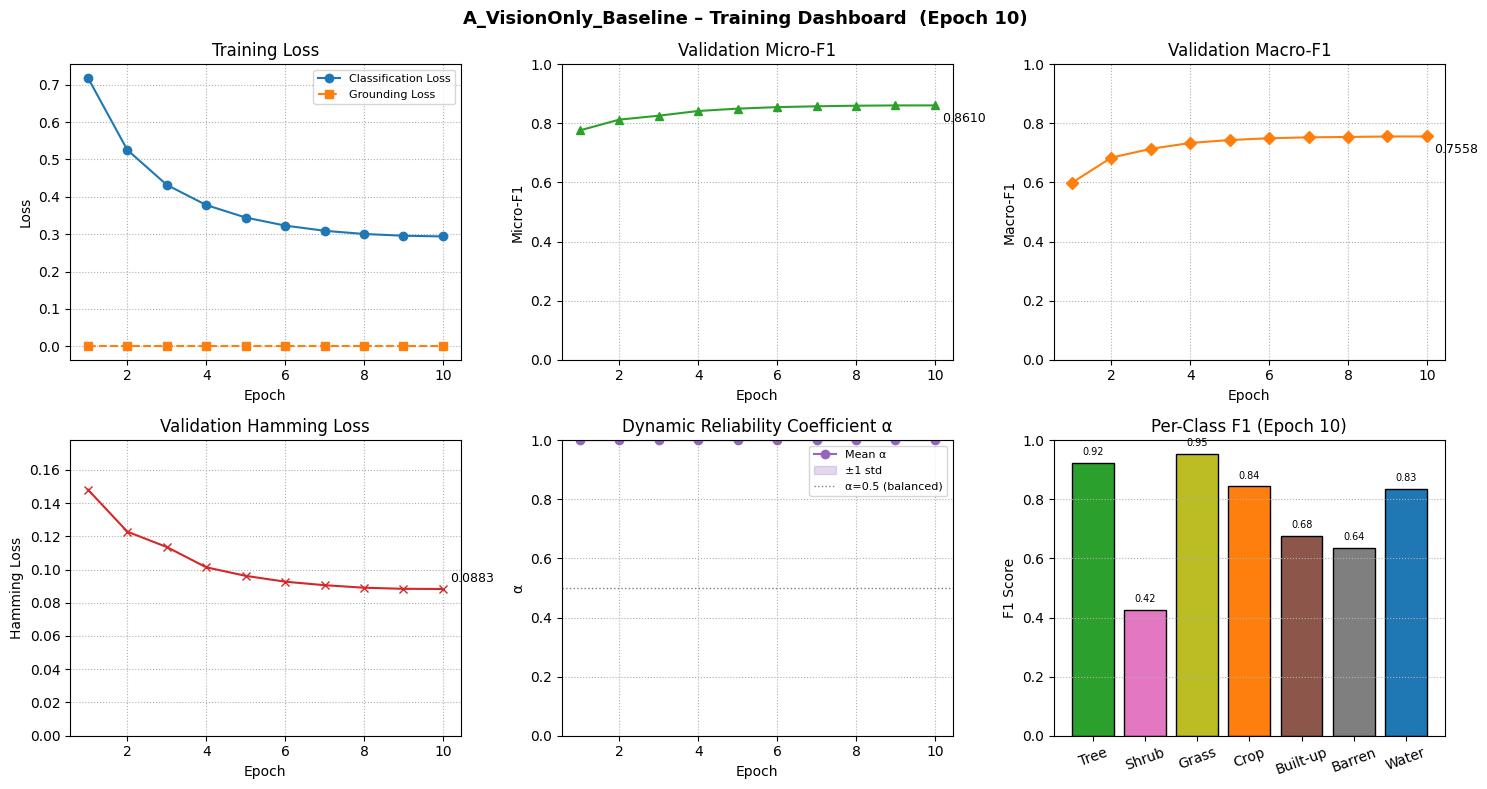


[A_VisionOnly_Baseline] Training complete. Best Val Micro-F1: 0.8610


epoch,▁▂▃▃▄▅▆▆▇█
train/alpha_mean,▁▁▁▁▁▁▁▁▁▁
train/alpha_std,▁▁▁▁▁▁▁▁▁▁
train/cls_loss,█▅▃▂▂▁▁▁▁▁
train/entropy_loss,▁▁▁▁▁▁▁▁▁▁
train/f1_Barren,▁▅▆▆▇▇████
train/f1_Built-up,▁▆▇▇▇█████
train/f1_Crop,▁▆▇▇██████
train/f1_Grass,▁▅▆▇▇█████
train/f1_Shrub,▁▅▆▇▇█████
+21,...


In [ ]:
# Compute class-imbalance weights from training split
# Load the same split used by build_dataloaders (same seed) to get train labels
_labels_df_full = pd.read_csv(LABELS_CSV)
_train_val_df, _ = train_test_split(_labels_df_full, test_size=TEST_SPLIT, random_state=SEED)
_train_df, _     = train_test_split(_train_val_df, test_size=VAL_SPLIT / (1 - TEST_SPLIT), random_state=SEED)

pos_weight = compute_pos_weights(_train_df, CLASSES, DEVICE)

#  WandB

# Experiment A: Vision-Only Baseline
set_seed(SEED)
model_A = VisionOnlyBaseline(num_classes=NUM_CLASSES, attn_grid=ATTN_GRID)
history_A = train_model(
    model=model_A,
    train_loader=train_loader, val_loader=val_loader,
    num_epochs=NUM_EPOCHS, lr=LEARNING_RATE,
    attn_loss_w=ATTN_LOSS_W, device=DEVICE,
    classes=CLASSES,
    use_attn_grounding=False,
    pos_weight=pos_weight,
    experiment_name='A_VisionOnly_Baseline',
)


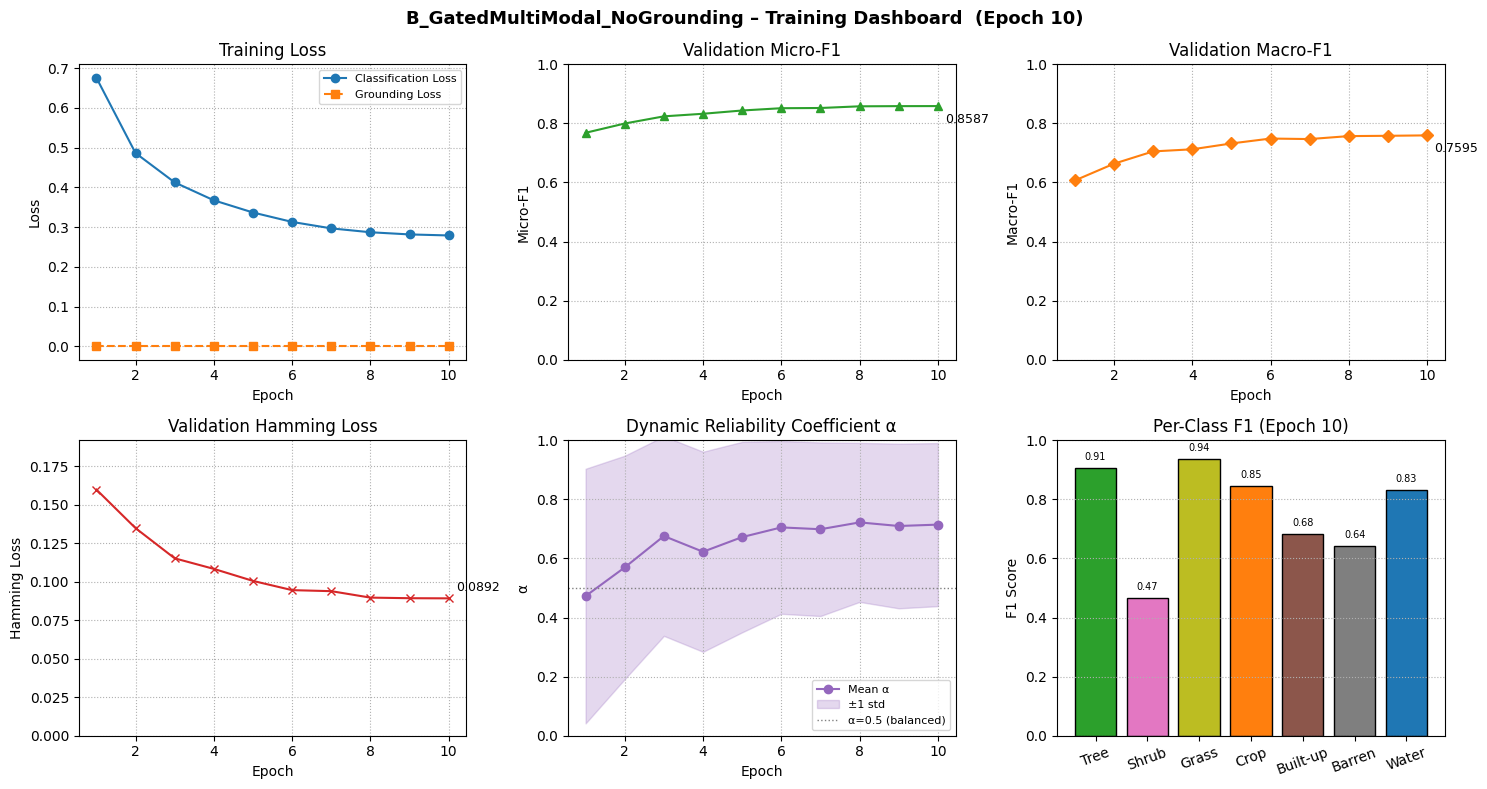


[B_GatedMultiModal_NoGrounding] Training complete. Best Val Micro-F1: 0.8587


epoch,▁▂▃▃▄▅▆▆▇█
train/alpha_mean,▁▄▅▆▇▇████
train/alpha_std,▆█▅▄▃▂▂▁▁▁
train/cls_loss,█▅▃▃▂▂▁▁▁▁
train/entropy_loss,▇▁▅▆▇▇████
train/f1_Barren,▁▄▅▆▇▇████
train/f1_Built-up,▁▄▅▆▆▇████
train/f1_Crop,▁▅▆▇▇█████
train/f1_Grass,▁▅▅▆▆▆▇▇██
train/f1_Shrub,▁▃▄▅▆▇▇▇██
+21,...


In [ ]:
# Experiment B: Gated Multi-Modal (no grounding)
set_seed(SEED)
model_B = GatedMultiModalModel(
    num_classes=NUM_CLASSES, attn_grid=ATTN_GRID,
    text_model_id=TEXT_MODEL_ID,
)
history_B = train_model(
    model=model_B,
    train_loader=train_loader, val_loader=val_loader,
    num_epochs=NUM_EPOCHS, lr=LEARNING_RATE,
    attn_loss_w=ATTN_LOSS_W, device=DEVICE,
    classes=CLASSES,
    use_attn_grounding=False,
    pos_weight=pos_weight,
    experiment_name='B_GatedMultiModal_NoGrounding',
)


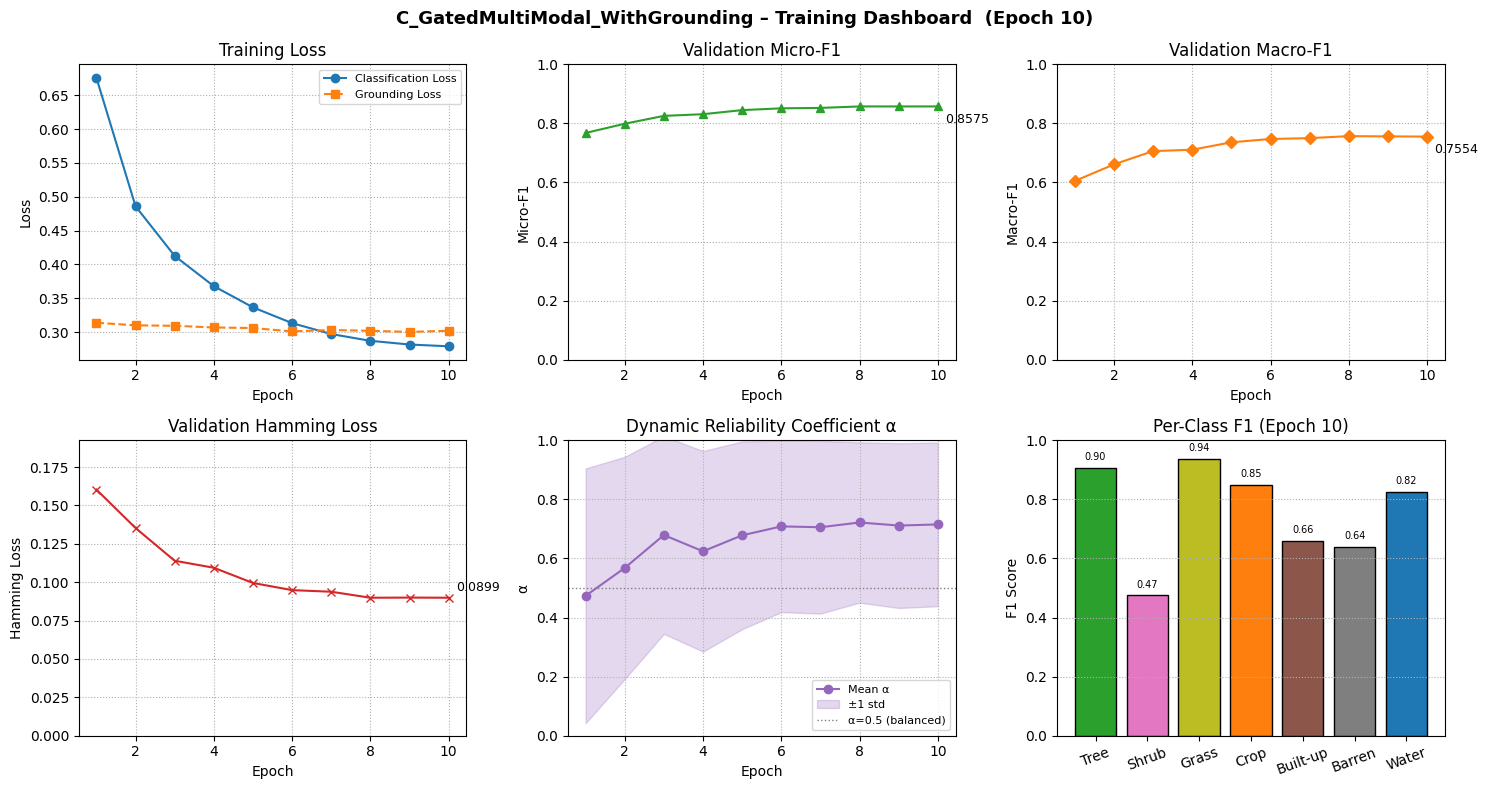


[C_GatedMultiModal_WithGrounding] Training complete. Best Val Micro-F1: 0.8575


epoch,▁▂▃▃▄▅▆▆▇█
train/alpha_mean,▁▄▅▆▇▇████
train/alpha_std,▆█▆▄▃▂▂▁▁▁
train/cls_loss,█▅▃▃▂▂▁▁▁▁
train/entropy_loss,▇▁▅▆▇▇████
train/f1_Barren,▁▄▆▆▇▇████
train/f1_Built-up,▁▄▅▆▆▇████
train/f1_Crop,▁▆▆▇▇▇████
train/f1_Grass,▁▅▆▆▆▆▇███
train/f1_Shrub,▁▃▄▅▆▇▇███
+21,...


In [ ]:
# Experiment C: Full Proposed Method (with per-class grounding)
set_seed(SEED)
model_C = GatedMultiModalModel(
    num_classes=NUM_CLASSES, attn_grid=ATTN_GRID,
    text_model_id=TEXT_MODEL_ID,
)
history_C = train_model(
    model=model_C,
    train_loader=train_loader, val_loader=val_loader,
    num_epochs=NUM_EPOCHS, lr=LEARNING_RATE,
    attn_loss_w=ATTN_LOSS_W, device=DEVICE,
    classes=CLASSES,
    use_attn_grounding=True,
    pos_weight=pos_weight,
    experiment_name='C_GatedMultiModal_WithGrounding',
)


## 8. Results

In [ ]:
def eval_on_test(
    model: nn.Module,
    test_loader: DataLoader,
    device: torch.device,
    attn_loss_w: float,
    classes: list,
    use_attn_grounding: bool,
    model_name: str,
) -> dict:
    """Load best checkpoint and evaluate on the held-out test set."""
    ckpt_path = f'{model_name}_best.pt'
    if os.path.exists(ckpt_path):
        model.load_state_dict(torch.load(ckpt_path, map_location=device))
        print(f"Loaded best checkpoint: {ckpt_path}")
    model.to(device)
    metrics = run_epoch(
        model, test_loader, None, device,
        attn_loss_w, classes, is_train=False,
        use_attn_grounding=use_attn_grounding,
    )
    return metrics


results = {}
results['A_VisionOnly'] = eval_on_test(
    model_A, test_loader, DEVICE, ATTN_LOSS_W, CLASSES,
    use_attn_grounding=False, model_name='A_VisionOnly_Baseline'
)
results['B_GatedNoGround'] = eval_on_test(
    model_B, test_loader, DEVICE, ATTN_LOSS_W, CLASSES,
    use_attn_grounding=False, model_name='B_GatedMultiModal_NoGrounding'
)
results['C_GatedGrounded'] = eval_on_test(
    model_C, test_loader, DEVICE, ATTN_LOSS_W, CLASSES,
    use_attn_grounding=True, model_name='C_GatedMultiModal_WithGrounding'
)

Loaded best checkpoint: A_VisionOnly_Baseline_best.pt
Loaded best checkpoint: B_GatedMultiModal_NoGrounding_best.pt
Loaded best checkpoint: C_GatedMultiModal_WithGrounding_best.pt


In [ ]:
# ── Summary table ─────────────────────────────────────────────────────────────
rows = []
for exp_name, m in results.items():
    rows.append({
        'Experiment':   exp_name,
        'Micro-F1':     round(m['micro_f1'],   4),
        'Macro-F1':     round(m['macro_f1'],   4),
        'Hamming Loss': round(m['hamming'],     4),
        'α (mean)':     round(m['alpha_mean'],  3),
        'α (std)':      round(m['alpha_std'],   3),
    })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))
summary_df.to_csv('phase2_results_summary.csv', index=False)

     Experiment  Micro-F1  Macro-F1  Hamming Loss  α (mean)  α (std)
   A_VisionOnly    0.8562    0.7523        0.0929     1.000    0.000
B_GatedNoGround    0.8634    0.7637        0.0879     0.721    0.276
C_GatedGrounded    0.8642    0.7633        0.0873     0.729    0.271


In [ ]:
#  Per-class F1 comparison
per_class_rows = []
for exp_name, m in results.items():
    row = {'Experiment': exp_name}
    for cls in CLASSES:
        row[cls] = round(m[f'f1_{cls}'], 4)
    per_class_rows.append(row)

per_class_df = pd.DataFrame(per_class_rows)
print(per_class_df.to_string(index=False))
per_class_df.to_csv('phase2_per_class_f1.csv', index=False)

     Experiment   Tree  Shrub  Grass   Crop  Built-up  Barren  Water
   A_VisionOnly 0.9172 0.4199 0.9493 0.8414    0.6222  0.6460 0.8704
B_GatedNoGround 0.9204 0.4805 0.9420 0.8487    0.7040  0.6574 0.7925
C_GatedGrounded 0.9175 0.4868 0.9427 0.8560    0.6880  0.6561 0.7961


## 9. Visualisations

All figures are exported at 300 DPI and saved as PNG files for inclusion in the report.

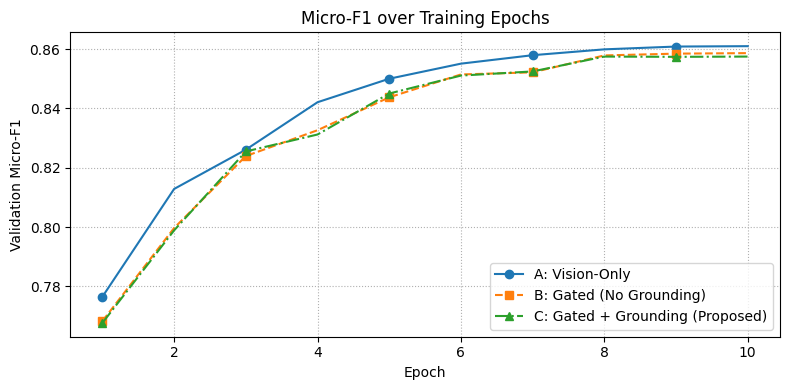

In [ ]:
# Validation Micro-F1 over epochs
fig, ax = plt.subplots(figsize=(8, 4))

linestyles = ['-', '--', '-.']
markers    = ['o', 's', '^']
labels_plot = ['A: Vision-Only', 'B: Gated (No Grounding)', 'C: Gated + Grounding (Proposed)']

for hist, ls, mk, lbl in zip(
    [history_A, history_B, history_C], linestyles, markers, labels_plot
):
    epochs = [e['epoch'] for e in hist]
    f1s    = [e['micro_f1'] for e in hist]
    ax.plot(epochs, f1s, linestyle=ls, marker=mk, label=lbl, markevery=2)

ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Micro-F1')
ax.set_title('Micro-F1 over Training Epochs')
ax.legend()
ax.grid(True, linestyle=':')
plt.tight_layout()
fig.savefig('fig1_micro_f1_epochs.png', dpi=300)
plt.show()

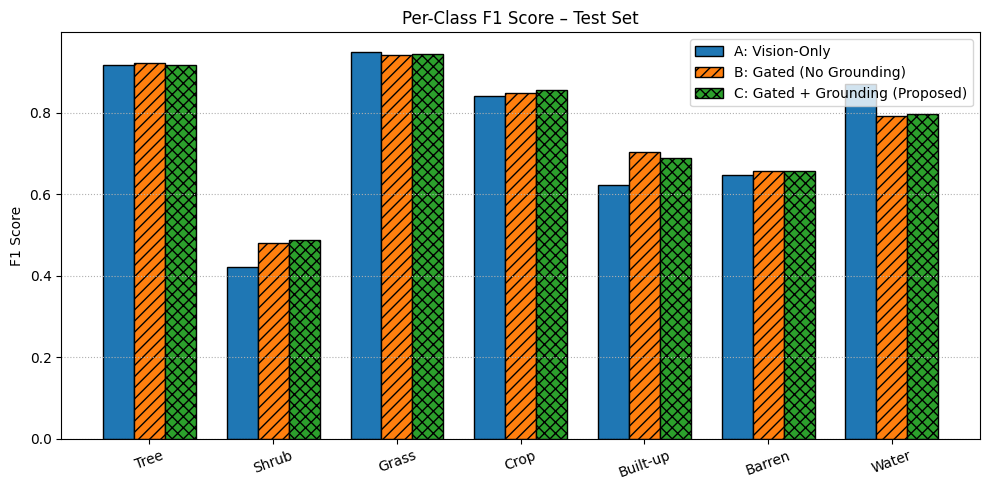

In [ ]:
#  Per-class F1 bar chart
x     = np.arange(len(CLASSES))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
hatches = ['', '///', 'xxx']

for i, (exp_name, lbl, hatch) in enumerate(
    zip(results.keys(), labels_plot, hatches)
):
    vals = [results[exp_name][f'f1_{cls}'] for cls in CLASSES]
    ax.bar(x + i * width, vals, width, label=lbl, hatch=hatch, edgecolor='black')

ax.set_xticks(x + width)
ax.set_xticklabels(CLASSES, rotation=20)
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1 Score – Test Set')
ax.legend()
ax.grid(axis='y', linestyle=':')
plt.tight_layout()
fig.savefig('fig2_per_class_f1.png', dpi=300)
plt.show()

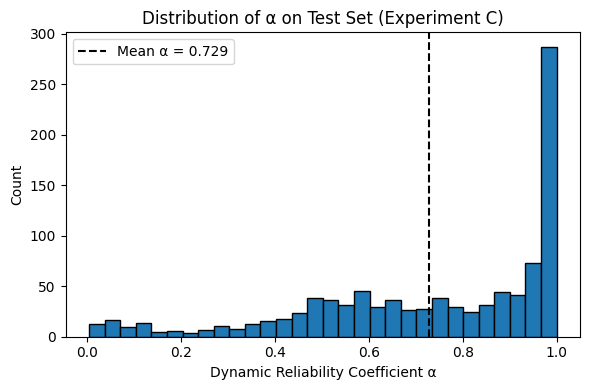

In [ ]:
# Alpha distribution for Experiment C
# Collect α values on the test set for qualitative analysis
model_C.eval()
alpha_vals = []

with torch.no_grad():
    for batch in test_loader:
        imgs     = batch['image'].to(DEVICE)
        ids      = batch['input_ids'].to(DEVICE)
        attn_msk = batch['attn_mask'].to(DEVICE)
        _, alpha, _ = model_C(imgs, ids, attn_msk)
        alpha_vals.append(alpha.cpu().squeeze(1).numpy())

alpha_vals = np.concatenate(alpha_vals)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(alpha_vals, bins=30, edgecolor='black')
ax.set_xlabel('Dynamic Reliability Coefficient α')
ax.set_ylabel('Count')
ax.set_title('Distribution of α on Test Set (Experiment C)')
ax.axvline(alpha_vals.mean(), color='k', linestyle='--', label=f'Mean α = {alpha_vals.mean():.3f}')
ax.legend()
plt.tight_layout()
fig.savefig('fig3_alpha_distribution.png', dpi=300)
plt.show()